# Dataset Understanding and Problem Formulation

This notebook studies the NASA C-MAPSS dataset for Remaining Useful Life prediction. The objective is to understand the dataset structure, define the RUL regression task, generate target labels, inspect feature behaviour, and identify data preparation requirements before baseline and multi-view modelling.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = '../data/raw/CMAPSS/'
FIG_DIR = '../reports/figures/'
TBL_DIR = '../reports/tables/'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

## 2. About C-MAPSS

C-MAPSS stands for Commercial Modular Aero-Propulsion System Simulation. It is a turbofan engine degradation simulation dataset published by NASA. Each engine unit starts in a healthy state and gradually degrades until failure. The dataset records sensor measurements at each operating cycle.

We start with FD001 because it is the simplest subset. It has one operating condition and one fault mode. This makes it suitable for establishing the first clean RUL pipeline before extending to more complex subsets.

## 3. Load FD001 Files

In [2]:
# Column schema for C-MAPSS files
# Columns: unit_number, time_in_cycles, op_setting_1..3, sensor_1..21

index_cols = ['unit_number', 'time_in_cycles']
op_cols = [f'operational_setting_{i}' for i in range(1, 4)]
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
all_cols = index_cols + op_cols + sensor_cols

print(f'Total columns expected: {len(all_cols)}')
print(f'Index columns: {index_cols}')
print(f'Operating settings: {len(op_cols)}')
print(f'Sensor measurements: {len(sensor_cols)}')

Total columns expected: 26
Index columns: ['unit_number', 'time_in_cycles']
Operating settings: 3
Sensor measurements: 21


In [3]:
train_df = pd.read_csv(
    f'{DATA_DIR}train_FD001.txt',
    sep='\\s+', header=None, names=all_cols
)

test_df = pd.read_csv(
    f'{DATA_DIR}test_FD001.txt',
    sep='\\s+', header=None, names=all_cols
)

rul_df = pd.read_csv(
    f'{DATA_DIR}RUL_FD001.txt',
    sep='\\s+', header=None, names=['RUL']
)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'RUL shape:   {rul_df.shape}')

Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL shape:   (100, 1)


## 4. Column Schema Documentation

| Column Group | Columns | Meaning |
|---|---|---|
| `unit_number` | 1 | Engine unit ID. Each ID is an independent degradation trajectory. |
| `time_in_cycles` | 1 | Operating cycle number within that engine's life. |
| `operational_setting_1..3` | 3 | Operating context (regime indicators for flight conditions). |
| `sensor_measurement_1..21` | 21 | Degradation-related sensor channels. |
| `RUL` | 1 | Target variable. Remaining cycles before failure. To be generated for training data. |

### Feature-wise Interpretation

| Feature Group | Columns | Dissertation Interpretation |
|---|---|---|
| Engine identity | `unit_number` | Engine trajectory identifier, not a model feature |
| Temporal index | `time_in_cycles` | Cycle number, used for sequencing and RUL derivation |
| Operating settings | `operational_setting_1..3` | Operating context or regime indicators |
| Sensor measurements | `sensor_measurement_1..21` | Degradation-related sensor channels |
| Target | `RUL` | Remaining useful life in cycles |

In C-MAPSS, sensor channels are benchmark variables representing engine measurements. Some are physically interpretable through dataset documentation, while others will be treated based on statistical and degradation behaviour during EDA. Exact physical meaning is not claimed for all sensors unless backed by documentation.

## 5. Dataset Basics

In [4]:
n_train_units = train_df['unit_number'].nunique()
n_test_units = test_df['unit_number'].nunique()

summary = pd.DataFrame({
    'Item': [
        'Training rows', 'Test rows',
        'Training units', 'Test units',
        'Operating settings', 'Sensor measurements',
        'Target', 'Task type'
    ],
    'Value': [
        train_df.shape[0], test_df.shape[0],
        n_train_units, n_test_units,
        3, 21,
        'RUL', 'Regression'
    ]
})

print(summary.to_string(index=False))
summary.to_csv(f'{TBL_DIR}dataset_summary_fd001.csv', index=False)
print(f'\nSaved to {TBL_DIR}dataset_summary_fd001.csv')

               Item      Value
      Training rows      20631
          Test rows      13096
     Training units        100
         Test units        100
 Operating settings          3
Sensor measurements         21
             Target        RUL
          Task type Regression

Saved to ../reports/tables/dataset_summary_fd001.csv


## 6. Machine Learning Task Definition

The machine learning task is Remaining Useful Life estimation. It is treated as a supervised regression problem because the target is a continuous numeric value representing the remaining number of operating cycles before failure.

One row represents a single sensor snapshot of a particular engine at a particular cycle. One engine unit is a full degradation trajectory from healthy to failure (in training) or healthy to some intermediate point (in test). One cycle is one operating step within that trajectory.

## 7. RUL Label Generation for Training Data

Since each training engine unit runs until failure, the final observed cycle can be treated as the failure cycle. The RUL at each cycle is computed as the difference between the final cycle and the current cycle.

A capped RUL target may be considered later during modelling if early-life RUL values dominate the learning problem.

In [5]:
# Compute RUL for training data
# RUL = max cycle for that unit - current cycle

max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

train_df = train_df.merge(max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

print('RUL column added to training data.')
print(f'RUL range: [{train_df["RUL"].min()}, {train_df["RUL"].max()}]')
print()
print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head(10))

RUL column added to training data.
RUL range: [0, 361]

   unit_number  time_in_cycles  RUL
0            1               1  191
1            1               2  190
2            1               3  189
3            1               4  188
4            1               5  187
5            1               6  186
6            1               7  185
7            1               8  184
8            1               9  183
9            1              10  182


## 8. Test RUL Handling

The test data does not run until failure. The provided `RUL_FD001.txt` file gives the remaining useful life after the final available test cycle for each test engine unit. This requires separate label construction for test evaluation.

During evaluation, predictions will be made on the last available window of each test engine, and compared against the ground truth RUL from this file.

In [6]:
print(f'Test RUL values: {len(rul_df)} entries')
print(f'Range: [{rul_df["RUL"].min()}, {rul_df["RUL"].max()}]')
print(f'Mean: {rul_df["RUL"].mean():.1f}, Std: {rul_df["RUL"].std():.1f}')
print()
print(rul_df.head(10))

Test RUL values: 100 entries
Range: [7, 145]
Mean: 75.5, Std: 41.8

   RUL
0  112
1   98
2   69
3   82
4   91
5   93
6   91
7   95
8  111
9   96


### Test-Set RUL Construction for All Test Rows

For test data, full run-to-failure sequences are not available. The provided RUL value represents the remaining cycles after the final observed test cycle. Therefore, an estimated failure cycle is computed for each test engine and used to derive RUL labels for all observed test cycles.

```
estimated_failure_cycle = last_observed_test_cycle + provided_final_RUL
RUL_at_each_test_cycle = estimated_failure_cycle - current_cycle
```

This construction allows evaluation at any point in the test trajectory, not only at the final cycle.

In [7]:
# Construct RUL labels for all test rows
# Step 1: get the last observed cycle for each test engine
test_max_cycles = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max_cycles.columns = ['unit_number', 'last_test_cycle']

# Step 2: add the provided final RUL to get estimated failure cycle
rul_df_indexed = rul_df.copy()
rul_df_indexed['unit_number'] = range(1, len(rul_df) + 1)

test_max_cycles = test_max_cycles.merge(rul_df_indexed, on='unit_number', how='left')
test_max_cycles['estimated_failure_cycle'] = test_max_cycles['last_test_cycle'] + test_max_cycles['RUL']

# Step 3: derive RUL at each test cycle
test_df = test_df.merge(
    test_max_cycles[['unit_number', 'estimated_failure_cycle']],
    on='unit_number', how='left'
)
test_df['RUL'] = test_df['estimated_failure_cycle'] - test_df['time_in_cycles']
test_df.drop(columns=['estimated_failure_cycle'], inplace=True)

print('Test RUL constructed for all rows.')
print(f'Test RUL range: [{test_df["RUL"].min()}, {test_df["RUL"].max()}]')
print()
print(test_df[['unit_number', 'time_in_cycles', 'RUL']].head(10))

Test RUL constructed for all rows.
Test RUL range: [7, 340]

   unit_number  time_in_cycles  RUL
0            1               1  142
1            1               2  141
2            1               3  140
3            1               4  139
4            1               5  138
5            1               6  137
6            1               7  136
7            1               8  135
8            1               9  134
9            1              10  133


## 9. Data Quality Checks

In [8]:
feature_cols = op_cols + sensor_cols

# Missing values
missing = train_df[feature_cols].isnull().sum()
print(f'Missing values in any column: {missing.sum()}')

# Duplicate rows
n_dupes = train_df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')

# Constant columns (zero variance)
variances = train_df[feature_cols].var()
constant_cols = variances[variances == 0].index.tolist()
print(f'Constant columns (zero variance): {constant_cols}')

# Low variance columns (variance < 0.001)
low_var_cols = variances[variances < 0.001].index.tolist()
print(f'Low-variance columns (var < 0.001): {low_var_cols}')

Missing values in any column: 0
Duplicate rows: 0
Constant columns (zero variance): ['operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_10', 'sensor_measurement_18', 'sensor_measurement_19']
Low-variance columns (var < 0.001): ['operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18', 'sensor_measurement_19']


In [9]:
# Build data quality summary table
quality_df = pd.DataFrame({
    'feature': feature_cols,
    'missing': [train_df[c].isnull().sum() for c in feature_cols],
    'min': [train_df[c].min() for c in feature_cols],
    'max': [train_df[c].max() for c in feature_cols],
    'mean': [train_df[c].mean() for c in feature_cols],
    'std': [train_df[c].std() for c in feature_cols],
    'variance': [train_df[c].var() for c in feature_cols]
})

quality_df['is_constant'] = quality_df['variance'] == 0
quality_df['is_low_var'] = quality_df['variance'] < 0.001

quality_df.to_csv(f'{TBL_DIR}data_quality_summary_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}data_quality_summary_fd001.csv')
print()
print(quality_df.to_string(index=False))

Saved to ../reports/tables/data_quality_summary_fd001.csv

              feature  missing       min       max        mean          std     variance  is_constant  is_low_var
operational_setting_1        0   -0.0087    0.0087   -0.000009 2.187313e-03 4.784340e-06        False        True
operational_setting_2        0   -0.0006    0.0006    0.000002 2.930621e-04 8.588541e-08        False        True
operational_setting_3        0  100.0000  100.0000  100.000000 0.000000e+00 0.000000e+00         True        True
 sensor_measurement_1        0  518.6700  518.6700  518.670000 0.000000e+00 0.000000e+00         True        True
 sensor_measurement_2        0  641.2100  644.5300  642.680934 5.000533e-01 2.500533e-01        False       False
 sensor_measurement_3        0 1571.0400 1616.9100 1590.523119 6.131150e+00 3.759099e+01        False       False
 sensor_measurement_4        0 1382.2500 1441.4900 1408.933782 9.000605e+00 8.101089e+01        False       False
 sensor_measurement_5        

### Feature Profile

A more detailed feature profile including unique value counts, which helps identify discrete vs continuous features and confirms constant/near-constant columns.

In [10]:
# Detailed feature profile
feature_profile = pd.DataFrame({
    'feature': feature_cols,
    'unique_count': [train_df[c].nunique() for c in feature_cols],
    'missing': [train_df[c].isnull().sum() for c in feature_cols],
    'min': [train_df[c].min() for c in feature_cols],
    'max': [train_df[c].max() for c in feature_cols],
    'mean': [train_df[c].mean() for c in feature_cols],
    'std': [train_df[c].std() for c in feature_cols],
    'variance': [train_df[c].var() for c in feature_cols],
})

feature_profile['is_constant'] = feature_profile['variance'] == 0
feature_profile['is_near_constant'] = (feature_profile['unique_count'] <= 3) | (feature_profile['variance'] < 0.0001)

feature_profile.to_csv(f'{TBL_DIR}feature_profile_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}feature_profile_fd001.csv')
print()
print(feature_profile.to_string(index=False))

Saved to ../reports/tables/feature_profile_fd001.csv

              feature  unique_count  missing       min       max        mean          std     variance  is_constant  is_near_constant
operational_setting_1           158        0   -0.0087    0.0087   -0.000009 2.187313e-03 4.784340e-06        False              True
operational_setting_2            13        0   -0.0006    0.0006    0.000002 2.930621e-04 8.588541e-08        False              True
operational_setting_3             1        0  100.0000  100.0000  100.000000 0.000000e+00 0.000000e+00         True              True
 sensor_measurement_1             1        0  518.6700  518.6700  518.670000 0.000000e+00 0.000000e+00         True              True
 sensor_measurement_2           310        0  641.2100  644.5300  642.680934 5.000533e-01 2.500533e-01        False             False
 sensor_measurement_3          3012        0 1571.0400 1616.9100 1590.523119 6.131150e+00 3.759099e+01        False             False
 sensor_

## 10. Cycle Count and RUL Distribution Analysis

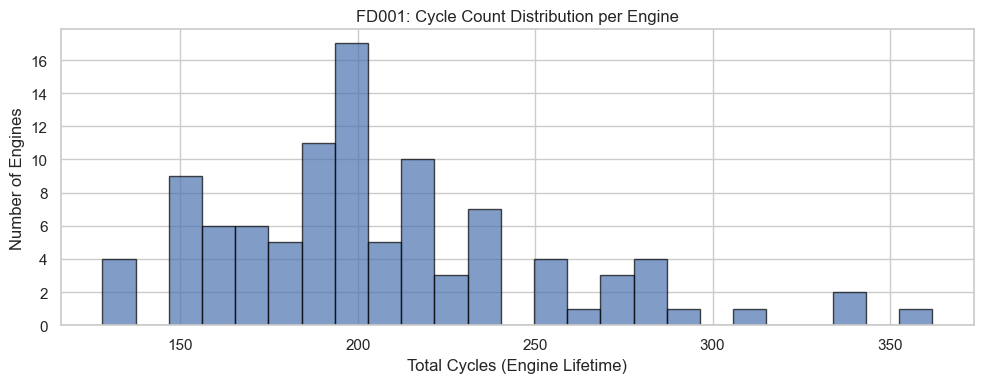

Shortest lifetime: 128 cycles
Longest lifetime:  362 cycles
Mean lifetime:     206.3 cycles


In [11]:
# Cycles per engine (i.e., engine lifetime in training set)
cycles_per_engine = train_df.groupby('unit_number')['time_in_cycles'].max()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cycles_per_engine, bins=25, edgecolor='black', alpha=0.7)
ax.set_xlabel('Total Cycles (Engine Lifetime)')
ax.set_ylabel('Number of Engines')
ax.set_title('FD001: Cycle Count Distribution per Engine')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}cycle_count_distribution_fd001.png', dpi=150)
plt.show()

print(f'Shortest lifetime: {cycles_per_engine.min()} cycles')
print(f'Longest lifetime:  {cycles_per_engine.max()} cycles')
print(f'Mean lifetime:     {cycles_per_engine.mean():.1f} cycles')

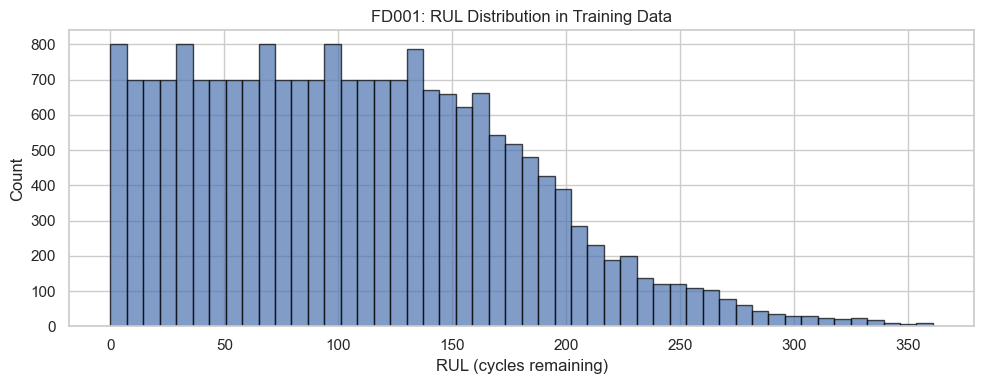

In [12]:
# RUL distribution in training data
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('RUL (cycles remaining)')
ax.set_ylabel('Count')
ax.set_title('FD001: RUL Distribution in Training Data')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}rul_distribution_fd001.png', dpi=150)
plt.show()

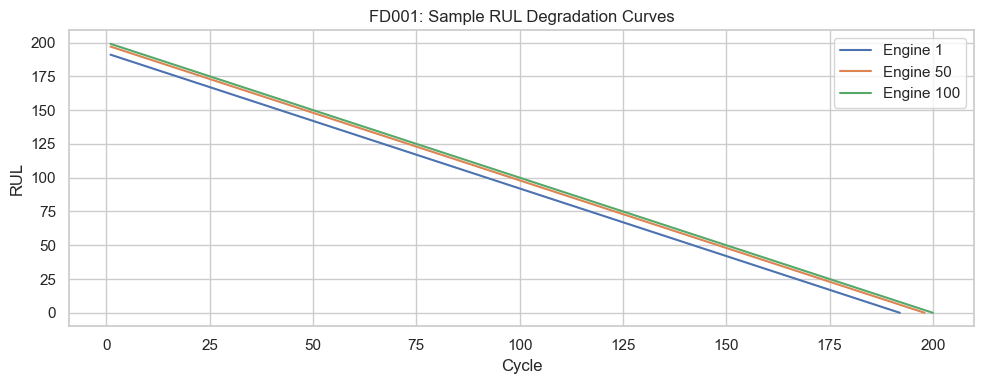

In [13]:
# Sample RUL degradation curves for 3 engines
sample_units = [1, 50, 100]

fig, ax = plt.subplots(figsize=(10, 4))
for unit in sample_units:
    unit_data = train_df[train_df['unit_number'] == unit]
    ax.plot(unit_data['time_in_cycles'], unit_data['RUL'], label=f'Engine {unit}')

ax.set_xlabel('Cycle')
ax.set_ylabel('RUL')
ax.set_title('FD001: Sample RUL Degradation Curves')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sample_rul_curves_fd001.png', dpi=150)
plt.show()

## 11. Initial Sensor Behaviour Analysis

The goal here is not final interpretation. It is to see whether some sensors show visible degradation trends over cycles.

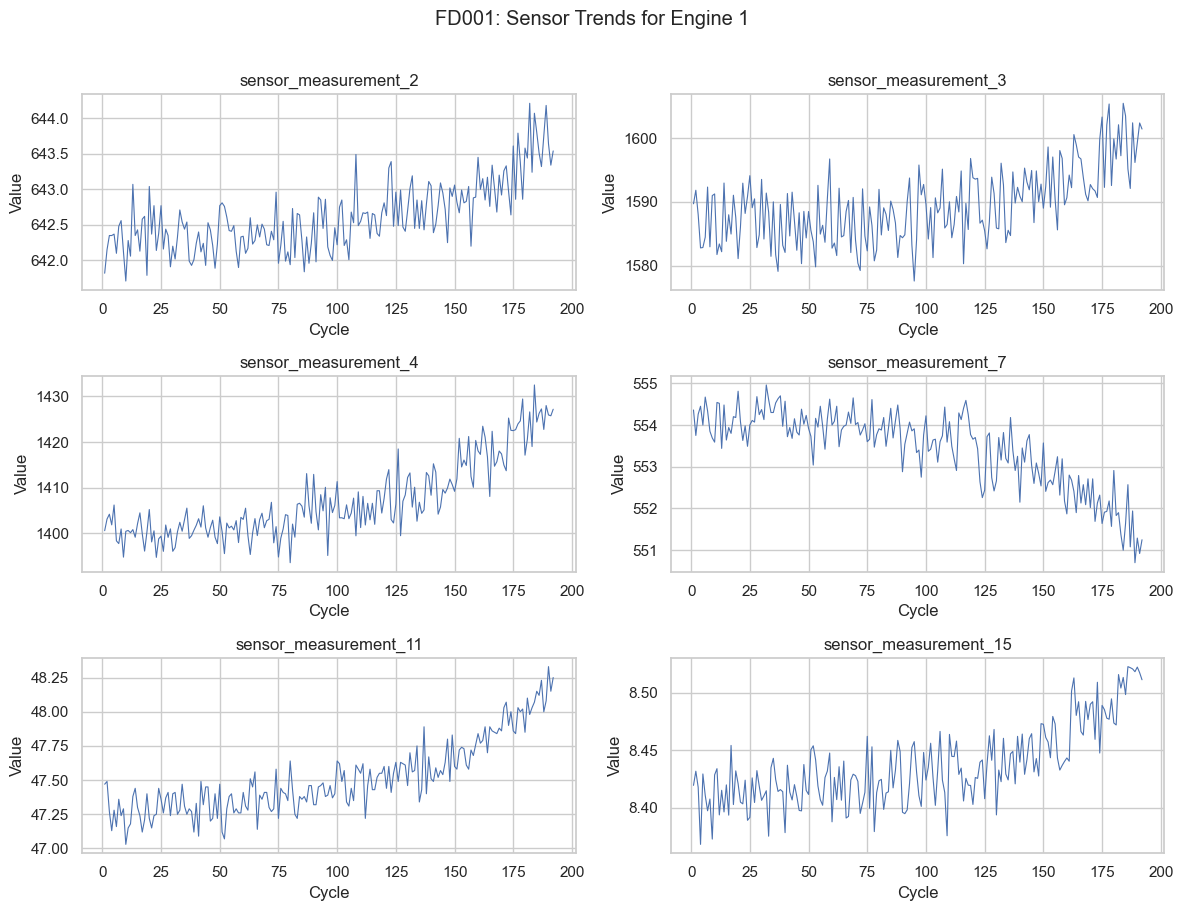

In [14]:
# Pick a few sensors that are likely informative and plot for a sample engine
sample_sensors = ['sensor_measurement_2', 'sensor_measurement_3',
                  'sensor_measurement_4', 'sensor_measurement_7',
                  'sensor_measurement_11', 'sensor_measurement_15']
sample_unit = 1

unit_data = train_df[train_df['unit_number'] == sample_unit]

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.flatten()

for i, sensor in enumerate(sample_sensors):
    axes[i].plot(unit_data['time_in_cycles'], unit_data[sensor], linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')

plt.suptitle(f'FD001: Sensor Trends for Engine {sample_unit}', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sample_sensor_trends_fd001.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sensor Correlation with RUL

This is initial EDA only. Correlation is not final feature importance, but it gives a starting point for understanding which sensors are related to degradation.

In [15]:
# Compute Pearson correlation of each sensor with RUL
# Constant sensors (zero variance) produce NaN correlation; fill with 0.0
corr_with_rul = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')
corr_with_rul = corr_with_rul.fillna(0.0)
corr_with_rul = corr_with_rul.sort_values(ascending=False)

corr_table = pd.DataFrame({
    'sensor': corr_with_rul.index,
    'correlation_with_rul': corr_with_rul.values
})

corr_table.to_csv(f'{TBL_DIR}sensor_rul_correlation_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}sensor_rul_correlation_fd001.csv')
print()
print(corr_table.to_string(index=False))

Saved to ../reports/tables/sensor_rul_correlation_fd001.csv

               sensor  correlation_with_rul
sensor_measurement_12              0.671983
 sensor_measurement_7              0.657223
sensor_measurement_21              0.635662
sensor_measurement_20              0.629428
sensor_measurement_10              0.000000
sensor_measurement_19              0.000000
sensor_measurement_18              0.000000
sensor_measurement_16              0.000000
 sensor_measurement_1              0.000000
 sensor_measurement_5              0.000000
 sensor_measurement_6             -0.128348
sensor_measurement_14             -0.306769
 sensor_measurement_9             -0.390102
sensor_measurement_13             -0.562569
 sensor_measurement_8             -0.563968
 sensor_measurement_3             -0.584520
sensor_measurement_17             -0.606154
 sensor_measurement_2             -0.606484
sensor_measurement_15             -0.642667
 sensor_measurement_4             -0.678948
sensor_measurem

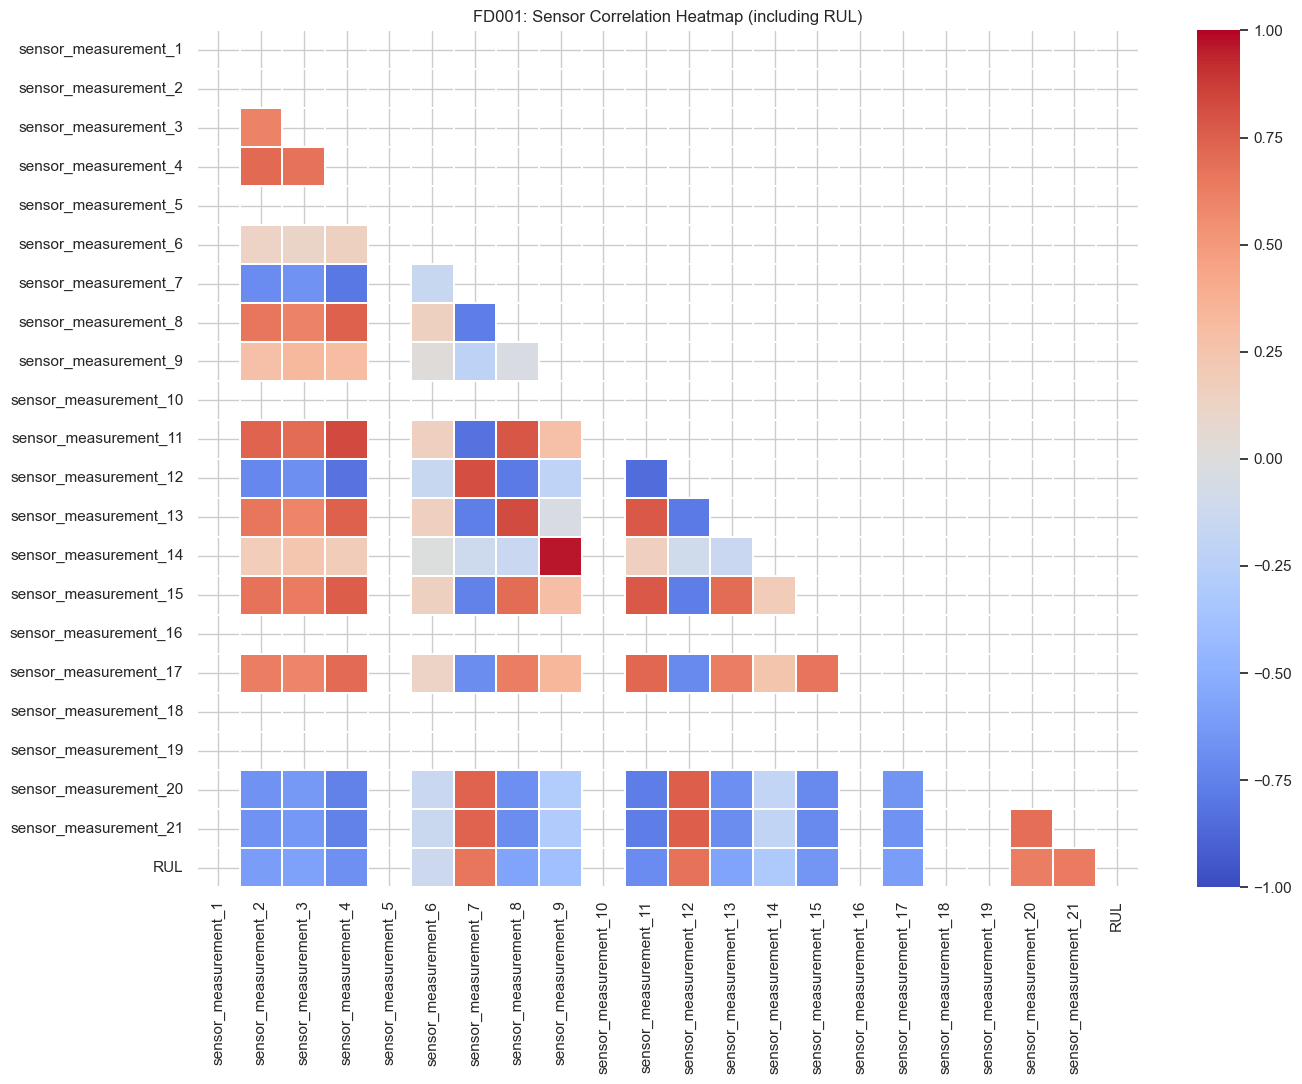

In [16]:
# Correlation heatmap of sensors + RUL
corr_matrix = train_df[sensor_cols + ['RUL']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1, ax=ax)
ax.set_title('FD001: Sensor Correlation Heatmap (including RUL)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}correlation_heatmap_fd001.png', dpi=150)
plt.show()

## 13. Train-Test Distribution Check

This is not a full drift analysis, but a basic comparison of feature means between training and test sets. Large differences could indicate distribution shift that affects model generalisation.

In [17]:
train_means = train_df[feature_cols].mean()
test_means = test_df[feature_cols].mean()

distribution_shift = pd.DataFrame({
    'feature': feature_cols,
    'train_mean': train_means.values,
    'test_mean': test_means.values,
    'abs_mean_diff': np.abs(train_means.values - test_means.values)
}).sort_values('abs_mean_diff', ascending=False)

distribution_shift.to_csv(f'{TBL_DIR}train_test_distribution_check_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}train_test_distribution_check_fd001.csv')
print()
print(distribution_shift.head(10).to_string(index=False))

Saved to ../reports/tables/train_test_distribution_check_fd001.csv

              feature  train_mean   test_mean  abs_mean_diff
 sensor_measurement_9 9065.242941 9058.407363       6.835577
sensor_measurement_14 8143.752722 8138.947817       4.804905
 sensor_measurement_4 1408.933782 1404.735362       4.198420
 sensor_measurement_3 1590.523119 1588.099204       2.423914
sensor_measurement_17  393.210654  392.571625       0.639029
 sensor_measurement_7  553.367711  553.757523       0.389812
sensor_measurement_12  521.413470  521.747724       0.334254
 sensor_measurement_2  642.680934  642.475088       0.205846
sensor_measurement_11   47.541168   47.416204       0.124964
sensor_measurement_20   38.816271   38.892502       0.076231


## 14. Leakage Prevention Strategy

Rows from the same engine unit are temporally related. Therefore, random row-level splitting can lead to leakage because records from the same degradation trajectory may appear in both training and validation sets. The modelling pipeline will avoid random row-wise splitting and will preserve engine-level or time-aware evaluation boundaries. Normalization parameters will be fitted only on training data and then applied to validation/test data.

## 15. Preliminary Multi-View Grouping

| Proposed View | Candidate Features |
|---|---|
| Raw sensor history | sensor measurements over time windows |
| Operating context | operational settings |
| Derived degradation indicators | rolling mean, rolling standard deviation, slope, delta from initial value |
| Derived context features | threshold flags, regime indicators, where feasible |

This grouping is preliminary. It will be refined after feature engineering and initial modelling results. The idea is that different views capture different aspects of the degradation process, which is the basis for the multi-view modelling approach in this dissertation.

### FD001 Limitation for Multi-View Framing

Since FD001 has one operating condition and one fault mode, the operating settings may have limited variation. Therefore, FD001 is mainly used to establish the RUL prediction and baseline pipeline. Richer operating-context analysis may require FD002 or FD004, which include multiple operating conditions. For FD001, the multi-view formulation will primarily rely on raw sensor history and derived degradation indicators, while operating context will be evaluated for usefulness based on variance and contribution.

## 16. Initial Observations

1. FD001 is suitable as the first subset for RUL regression pipeline development.
2. Each engine unit represents an independent degradation trajectory.
3. The target variable is RUL, making the primary task a regression problem.
4. RUL labels can be generated for training data using final cycle minus current cycle.
5. Test data requires provided RUL values because test trajectories stop before failure.
6. Random row-level splitting should be avoided due to temporal and unit-level leakage risk.
7. Operating settings and sensor measurements provide the basis for industrial multi-view grouping.
8. EDA outputs will guide feature filtering, baseline model selection, and derived degradation feature design.
9. Some sensors show near-zero variance in FD001 and will be reviewed for possible removal before modelling.
10. Correlation with RUL gives an initial indication of sensor informativeness, but monotonic and non-linear relationships need further investigation.

## 17. EDA Implications for Modelling

1. RUL prediction is a regression problem.
2. FD001 can be used to establish the first clean RUL pipeline.
3. Random row-level splitting should be avoided.
4. Constant and low-variance sensors should be reviewed before modelling.
5. Sensor history supports time-window-based deep learning models.
6. Operating context in FD001 may have limited value due to one operating condition.
7. Derived degradation indicators can be engineered using rolling statistics and slopes.
8. Initial baselines should include tree-based models such as Random Forest and XGBoost alongside simple sequence models.
9. The train-test distribution comparison will be used as an initial check for feature-level differences between training and test data. More detailed validation will be performed during modelling.

In [18]:
print("Generated tables:")
for f in sorted(os.listdir(TBL_DIR)):
    print("-", f)

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("-", f)

Generated tables:
- .gitkeep
- data_quality_summary_fd001.csv
- dataset_summary_fd001.csv
- feature_profile_fd001.csv
- sensor_rul_correlation_fd001.csv
- train_test_distribution_check_fd001.csv

Generated figures:
- .gitkeep
- correlation_heatmap_fd001.png
- cycle_count_distribution_fd001.png
- rul_distribution_fd001.png
- sample_rul_curves_fd001.png
- sample_sensor_trends_fd001.png
